# Desarrollo de modelo de aprendizaje automatico para evitar la fuga de clientes de un programa de fidelidad
Misión:

 Desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

🧠 Objetivos del Desafío

usar el Churn como metodo de aprendizaje automatico donde Churn significa si la persona a abandonado o no el programa de fidelidad de Telecom X y predecir valores futuros para evitar el abandono de clientes al programa. **texto en negrita**

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

🧰 Lo que vas a practicar

✅ Preprocesamiento de datos para Machine Learning
✅ Construcción y evaluación de modelos predictivos
✅ Interpretación de resultados y entrega de insights
✅ Comunicación técnica con enfoque estratégico

🚀 Ahora eres: Analista Junior de Machine Learning

Telecom X confía en tu entrega para dar los próximos pasos hacia una solución de inteligencia predictiva eficaz. ¡Buena suerte!




# 🛠️ Preparación de los Datos

## Extracción del Archivo Tratado
Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

importando librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
datos  = pd.read_csv('/content/drive/MyDrive/Reto_de_predicción_de_evasion_de_clientes/datos_tratados.csv')

## Eliminación de Columnas
Descripción
Editar
Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

Explorando columnas para ver cuales no son relevantes

In [ ]:
datos.columns

Index(['customerID', 'Churn', 'PhoneService', 'MultipleLines', 'gender',
       'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'Charges.Monthly', 'Charges.Total', 'Months_Paid',
       'Cuentas_Diarias'],
      dtype='object')

eliminando customerID

In [ ]:
datos = datos.drop('customerID', axis=1)
datos.head()

,Churn,PhoneService,MultipleLines,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Months_Paid,Cuentas_Diarias
0,No,Yes,No,Female,0,Yes,Yes,9,DSL,No,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,9.044207,271.326220
1,No,Yes,Yes,Male,0,No,No,9,DSL,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,9.055092,271.652755
2,Yes,Yes,No,Male,0,No,No,4,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,3.800406,114.012179
3,Yes,Yes,No,Male,1,Yes,No,13,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,12.631122,378.933673
4,Yes,Yes,No,Female,1,Yes,No,3,Fiber optic,No,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,3.187128,95.613826


## Encoding
Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

🔎 Sugerencia:
Puedes consultar este artículo para entender mejor cuándo usar get_dummies o OneHotEncoder:
Hay una forma muy simple de hacer esta transformación usando la biblioteca pandas, a partir de la función pd.get_dummies(), sin embargo, no es un método muy recomendado cuando estamos trabajando con Machine Learning, ya que esta función no puede abstraer y ejecutar la misma transformación para un nuevo dato. Si tienes una nueva información que pertenece solo a una de las clases de una variable objetivo, el proceso de get_dummies no será capaz de generar las otras columnas provenientes de las otras clases. Esto se convierte en un problema para el modelo, ya que espera todas las características para realizar una predicción.

El método más recomendado para realizar la transformación en proyectos de Machine Learning es el OneHotEncoder. En un primer momento, con los datos iniciales, comienza su acción comprendiendo las características de los datos y genera las nuevas columnas para cada clase. Además, almacena la regla capaz de hacer este procedimiento para nuevos datos. Por lo tanto, en el proceso de transformación de un nuevo dato, puede crear todas las columnas necesarias, aunque este nuevo dato tenga solo la información de una de las clases.

In [ ]:
#encontrando nuestras variables categóricas
datos.select_dtypes(include='object').columns

Index(['Churn', 'PhoneService', 'MultipleLines', 'gender', 'Partner',
       'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

variables Categóricas

'Churn',
'PhoneService',
'MultipleLines',
'gender',
'Partner',
'Dependents',
'InternetService',
'OnlineSecurity',
'OnlineBackup',
'DeviceProtection',
'TechSupport',
'StreamingTV',
'StreamingMovies',
'Contract',
'PaperlessBilling',
'PaymentMethod'

In [ ]:
datos


,Churn,PhoneService,MultipleLines,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Months_Paid,Cuentas_Diarias
0,No,Yes,No,Female,0,Yes,Yes,9,DSL,No,...,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,9.044207,271.326220
1,No,Yes,Yes,Male,0,No,No,9,DSL,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,9.055092,271.652755
2,Yes,Yes,No,Male,0,No,No,4,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,3.800406,114.012179
3,Yes,Yes,No,Male,1,Yes,No,13,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,12.631122,378.933673
4,Yes,Yes,No,Female,1,Yes,No,3,Fiber optic,No,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,3.187128,95.613826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,Yes,No,Female,0,No,No,13,DSL,Yes,...,Yes,No,No,One year,No,Mailed check,55.15,742.90,13.470535,404.116047
7028,Yes,Yes,Yes,Male,0,Yes,No,22,Fiber optic,No,...,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,22.017626,660.528790
7029,No,Yes,No,Male,0,No,No,2,DSL,No,...,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.843936,55.318091
7030,No,Yes,No,Male,0,Yes,Yes,67,DSL,Yes,...,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,68.204127,2046.123802


Variables explicativas y variable de respuesta
Para realizar la predicción de los valores con un modelo de aprendizaje automático, necesitamos separar la variable objetivo de las variables explicativas. La variable y representa lo que queremos predecir, mientras que x incluye todas las variables que se utilizarán para explicar el comportamiento de y.

In [ ]:
X = datos.drop('Churn', axis=1)
y = datos['Churn']

In [ ]:
X

,PhoneService,MultipleLines,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Months_Paid,Cuentas_Diarias
0,Yes,No,Female,0,Yes,Yes,9,DSL,No,Yes,...,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,9.044207,271.326220
1,Yes,Yes,Male,0,No,No,9,DSL,No,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,9.055092,271.652755
2,Yes,No,Male,0,No,No,4,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,3.800406,114.012179
3,Yes,No,Male,1,Yes,No,13,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,12.631122,378.933673
4,Yes,No,Female,1,Yes,No,3,Fiber optic,No,No,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,3.187128,95.613826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,Yes,No,Female,0,No,No,13,DSL,Yes,No,...,Yes,No,No,One year,No,Mailed check,55.15,742.90,13.470535,404.116047
7028,Yes,Yes,Male,0,Yes,No,22,Fiber optic,No,No,...,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,22.017626,660.528790
7029,Yes,No,Male,0,No,No,2,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.843936,55.318091
7030,Yes,No,Male,0,Yes,Yes,67,DSL,Yes,No,...,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,68.204127,2046.123802


In [ ]:
y

,Churn
0,No
1,No
2,Yes
3,Yes
4,Yes
...,...
7027,No
7028,Yes
7029,No
7030,No


Transformando las variables explicativas
Los algoritmos de aprendizaje automático no comprenden datos en formato de texto, por lo que debemos transformar los datos a un formato numérico para que el algoritmo pueda interpretar la información. Esta transformación debe realizarse de manera que no altere la información original del conjunto de datos, por lo que no basta con simplemente cambiar los valores a números aleatorios.

In [ ]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
columnas = X.columns

In [ ]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['PhoneService',
     'MultipleLines',
     'gender',
     'Partner',
     'Dependents',
     'InternetService',
     'OnlineSecurity',
     'OnlineBackup',
     'DeviceProtection',
     'TechSupport',
     'StreamingTV',
     'StreamingMovies',
     'Contract',
     'PaperlessBilling',
     'PaymentMethod']
),
    remainder = 'passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False)

In [ ]:
X = one_hot.fit_transform(X)

In [ ]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__PhoneService_Yes',
       'onehotencoder__MultipleLines_No',
       'onehotencoder__MultipleLines_No phone service',
       'onehotencoder__MultipleLines_Yes', 'onehotencoder__gender_Male',
       'onehotencoder__Partner_Yes', 'onehotencoder__Dependents_Yes',
       'onehotencoder__InternetService_DSL',
       'onehotencoder__InternetService_Fiber optic',
       'onehotencoder__InternetService_No',
       'onehotencoder__OnlineSecurity_No',
       'onehotencoder__OnlineSecurity_No internet service',
       'onehotencoder__OnlineSecurity_Yes',
       'onehotencoder__OnlineBackup_No',
       'onehotencoder__OnlineBackup_No internet service',
       'onehotencoder__OnlineBackup_Yes',
       'onehotencoder__DeviceProtection_No',
       'onehotencoder__DeviceProtection_No internet service',
       'onehotencoder__DeviceProtection_Yes',
       'onehotencoder__TechSupport_No',
       'onehotencoder__TechSupport_No internet service',
       'onehotencoder__TechSupport_Ye

In [ ]:
pd.DataFrame(X, columns = one_hot.get_feature_names_out(columnas))

,onehotencoder__PhoneService_Yes,onehotencoder__MultipleLines_No,onehotencoder__MultipleLines_No phone service,onehotencoder__MultipleLines_Yes,onehotencoder__gender_Male,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,...,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,remainder__SeniorCitizen,remainder__tenure,remainder__Charges.Monthly,remainder__Charges.Total,remainder__Months_Paid,remainder__Cuentas_Diarias
0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,9.0,65.60,593.30,9.044207,271.326220
1,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,9.0,59.90,542.40,9.055092,271.652755
2,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,4.0,73.90,280.85,3.800406,114.012179
3,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,13.0,98.00,1237.85,12.631122,378.933673
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,3.0,83.90,267.40,3.187128,95.613826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,13.0,55.15,742.90,13.470535,404.116047
7028,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,22.0,85.10,1873.70,22.017626,660.528790
7029,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,50.30,92.75,1.843936,55.318091
7030,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,67.0,67.85,4627.65,68.204127,2046.123802


**Transformando la variable respuesta**

Así como las variables explicativas, la variable objetivo también debe convertirse al formato numérico. Podemos representar una variable objetivo binaria como 0 o 1, donde 0 indica la ausencia de la característica de la variable y 1 representa su presencia.

In [ ]:
from sklearn.preprocessing import LabelEncoder


In [ ]:
label_encoder = LabelEncoder()

In [ ]:
y = label_encoder.fit_transform(y)

In [ ]:
y

array([0, 0, 1, ..., 0, 0, 0])

# Verificación de la Proporción de Cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:

In [ ]:
import pandas as pd

churn_proportion = pd.Series(y).value_counts(normalize=True)
print("Proportion of customers who churned vs. active:")
print(churn_proportion)

Proportion of customers who churned vs. active:
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [ ]:
pd.Series(y).value_counts()

,count
0,5163
1,1869


tenemos en y 5163 valores con 0 y 1869 con 1 una relacion de 73.4% y 26.57% respectivamente osea que está desvalanceado

# Balanceo de Clases (opcional)
Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

🔎 Sugerencia:
Puedes leer más sobre cómo manejar el desbalanceo de clases en este artículo:
https://www.alura.com.br/artigos/lidando-com-desbalanceamento-dados?srsltid=AfmBOopTgyC_tpujwkC778gYjcLituqgxknih2Cr4vD72_OFHSB4v35M


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [ ]:
import pandas as pd
"""
under_sampling = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = under_sampling.fit_resample(X, y)
print("Shape of X before undersampling:", X.shape)
print("Shape of X after undersampling:", X_resampled.shape)

print("\nProportion of classes in y before undersampling:")
print(pd.Series(y).value_counts(normalize=True))

print("\nProportion of classes in y after undersampling:")
print(pd.Series(y_resampled).value_counts(normalize=True))
"""
#Se aplicó un oversampling porque era mejor al final del modelo

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Shape of X before SMOTE:", X.shape)
print("Shape of X after SMOTE:", X_resampled.shape)

print("\nProportion of classes in y before SMOTE:")
print(pd.Series(y).value_counts(normalize=True))

print("\nProportion of classes in y after SMOTE:")
print(pd.Series(y_resampled).value_counts(normalize=True))



Shape of X before SMOTE: (7032, 42)
Shape of X after SMOTE: (10326, 42)

Proportion of classes in y before SMOTE:
0    0.734215
1    0.265785
Name: proportion, dtype: float64

Proportion of classes in y after SMOTE:
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
pd.Series(y_resampled).value_counts()

,count
0,5163
1,5163


# Normalización o Estandarización (si es necesario)

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

🔎 Sugerencia:
Puedes leer más sobre normalización y estandarización de datos en este artículo:
https://medium.com/ipnet-growth-partner/padronizacao-normalizacao-dados-machine-learning-f8f29246c12

# 🎯 Correlación y Selección de Variables

## Análisis de Correlación
Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

/tmp/ipython-input-3445472488.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_correlation.values, y=churn_correlation.index, palette='coolwarm')


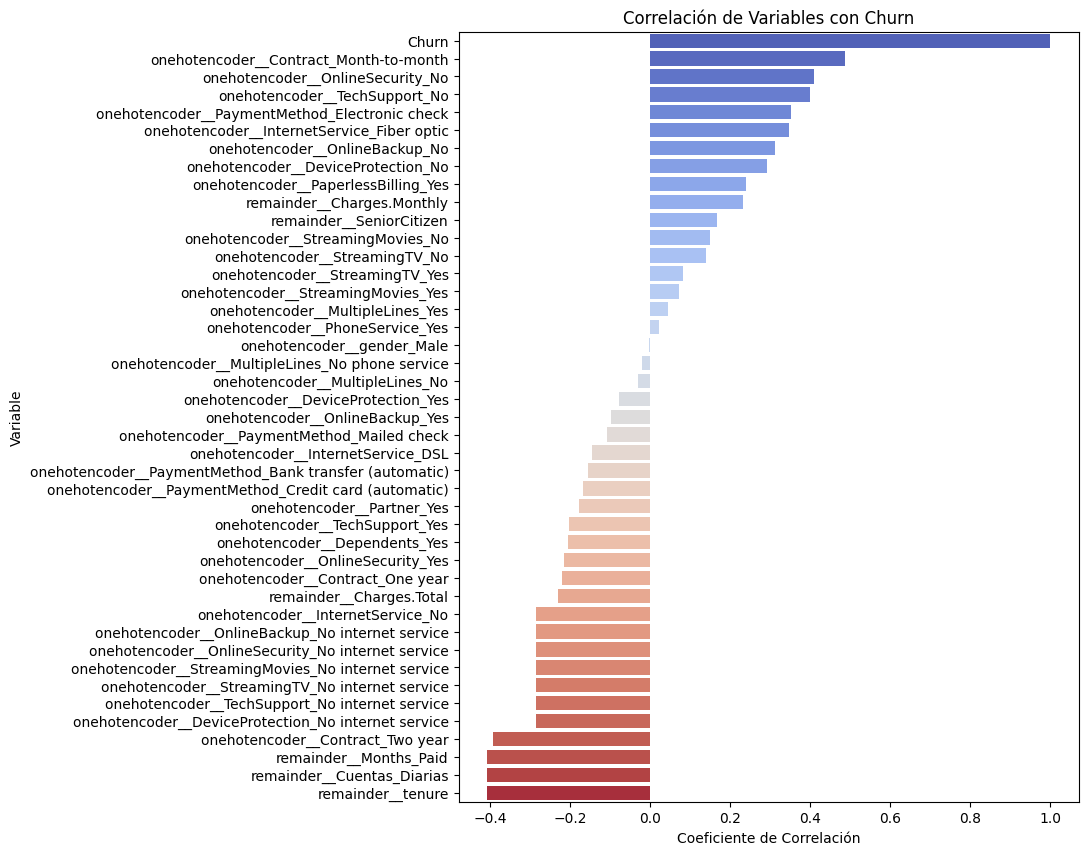


Correlación de variables con 'Churn':


,Churn
Churn,1.000000
onehotencoder__Contract_Month-to-month,0.487913
onehotencoder__OnlineSecurity_No,0.409295
onehotencoder__TechSupport_No,0.398773
onehotencoder__PaymentMethod_Electronic check,0.351220
onehotencoder__InternetService_Fiber optic,0.347757
onehotencoder__OnlineBackup_No,0.310899
onehotencoder__DeviceProtection_No,0.292380
onehotencoder__PaperlessBilling_Yes,0.239115
remainder__Charges.Monthly,0.230759


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Concatenamos la variable respuesta (y_resampled) con las variables explicativas (X_resampled)
# para calcular la correlación con 'Churn'.
# Primero convertimos X_resampled (numpy array) a DataFrame para facilitar la concatenación.
# Necesitamos obtener los nombres de las columnas transformadas.
feature_names = one_hot.get_feature_names_out(columnas)
X_resampled_df = pd.DataFrame(X_resampled, columns=feature_names)

# Añadimos la columna 'Churn' al DataFrame
X_resampled_df['Churn'] = y_resampled

# Calculate the correlation matrix
correlation_matrix = X_resampled_df.corr()

# Opcional: Visualizar solo las correlaciones con 'Churn' y ordenarlas
churn_correlation = correlation_matrix['Churn'].sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=churn_correlation.values, y=churn_correlation.index, palette='coolwarm')
plt.title('Correlación de Variables con Churn')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Variable')
plt.show()

print("\nCorrelación de variables con 'Churn':")
churn_correlation

## Análisis Dirigido
Investiga cómo variables específicas se relacionan con la cancelación, tales como:

Tiempo de contrato × Cancelación

Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

In [ ]:
datos.columns

Index(['Churn', 'PhoneService', 'MultipleLines', 'gender', 'SeniorCitizen',
       'Partner', 'Dependents', 'tenure', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total', 'Months_Paid', 'Cuentas_Diarias'],
      dtype='object')

Boxplot de Charges.Total por tipo de contrato y estado de Churn

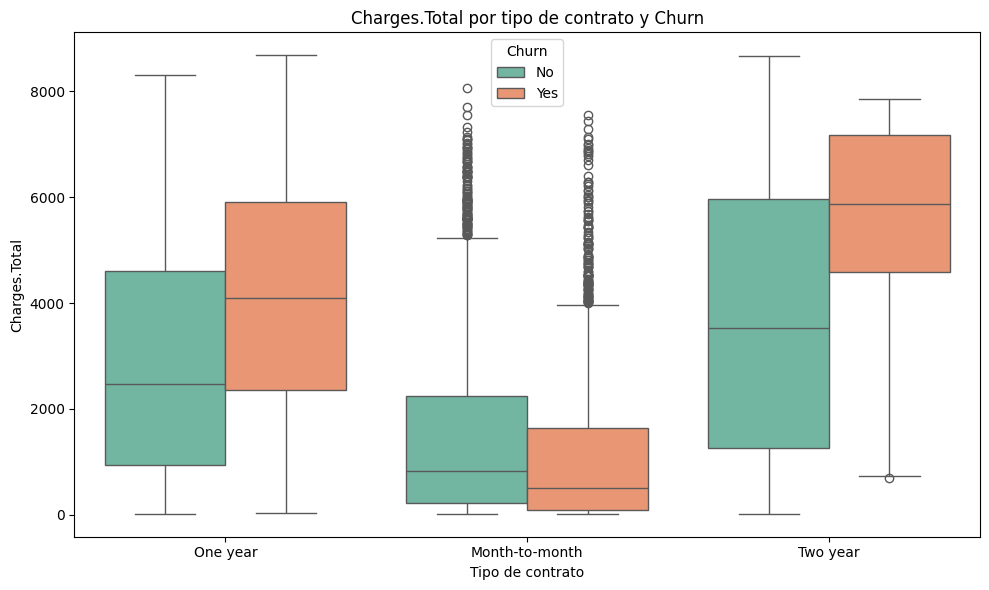

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=datos, x='Contract', y='Charges.Total', hue='Churn', palette='Set2')
plt.title('Charges.Total por tipo de contrato y Churn')
plt.xlabel('Tipo de contrato')
plt.ylabel('Charges.Total')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()



Scatter Plot: Charges.Total vs Months_Paid, segmentado por tipo de contrato

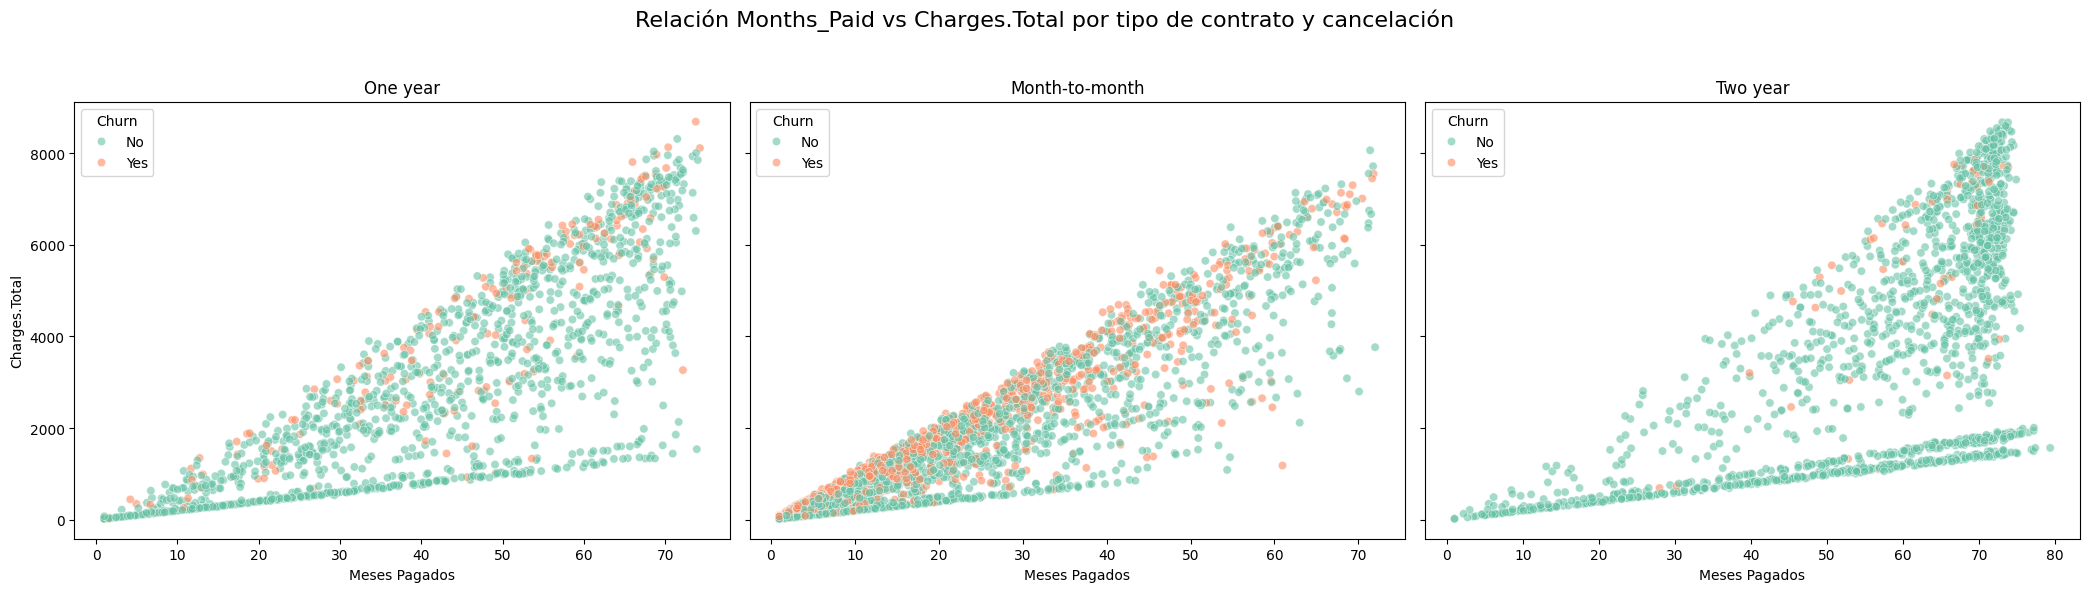

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de tipos de contrato
tipos_contrato = datos['Contract'].unique()

# Crear figura y subplots
fig, axs = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
plt.suptitle('Relación Months_Paid vs Charges.Total por tipo de contrato y cancelación', fontsize=16)

# Crear cada scatter plot por tipo de contrato
for i, contrato in enumerate(tipos_contrato):
    subset = datos[datos['Contract'] == contrato]
    sns.scatterplot(data=subset,
                    x='Months_Paid',
                    y='Charges.Total',
                    hue='Churn',
                    palette='Set2',
                    alpha=0.6,
                    ax=axs[i])

    axs[i].set_title(f'{contrato}')
    axs[i].set_xlabel('Meses Pagados')
    if i == 0:
        axs[i].set_ylabel('Charges.Total')
    else:
        axs[i].set_ylabel('')
    axs[i].legend(title='Churn')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# 🤖 Modelado Predictivo

## Separación de Datos
Descripción
Editar
Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)


## Creación de Modelos
Descripción

Editar

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

**Modelo 1 arbol de desicion**

Árboles de Decisión

El modelo de árbol de decisión es muy utilizado debido a su alta explicabilidad y procesamiento rápido, manteniendo un rendimiento bastante interesante.

Se basa en decisiones simples tomadas por el algoritmo, separando los datos mediante comparaciones de menor y mayor en los valores de las columnas de la base de datos.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arbol.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
modelo_arbol.score(X_train, y_train)


0.8233259546209186

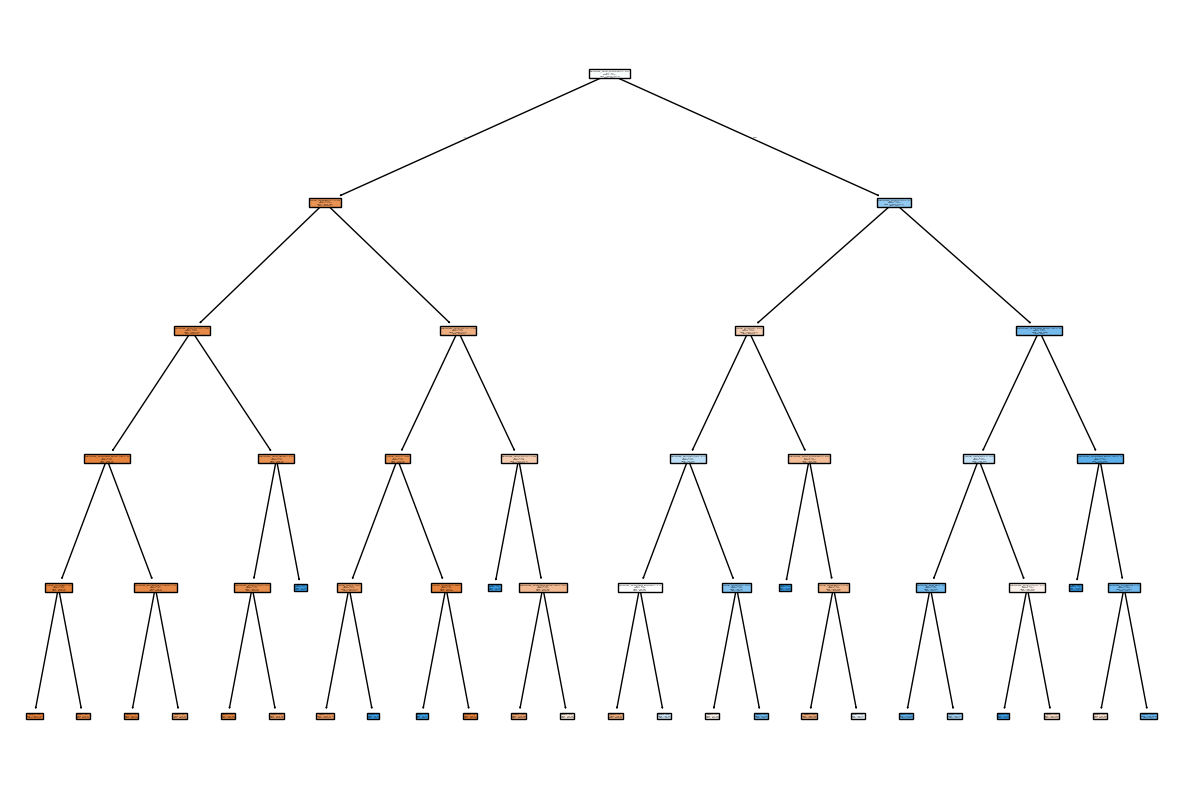

In [ ]:
# viendo un grafico del modelo de mi arbol de desición
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
plot_tree(modelo_arbol, filled=True, feature_names=one_hot.get_feature_names_out(columnas), class_names=['No Churn', 'Churn'])
plt.show()


**Modelo 2 KNN**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train)

In [ ]:
pd.DataFrame(X_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
0,1.0,1.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.000000,1.000000,0.0,0.042254,0.010511,0.006866,3.891977e-02,3.891977e-02
1,0.0,0.0,1.0,0.0,0.000000,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.000000,0.000000,0.0,0.985915,0.395896,0.476240,9.212728e-01,9.212728e-01
2,1.0,1.0,0.0,0.0,1.000000,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.000000,0.000000,1.0,0.056338,0.708709,0.052954,5.694335e-02,5.694335e-02
3,1.0,1.0,0.0,0.0,1.000000,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.000000,1.000000,0.0,0.000000,0.256256,0.002943,4.019701e-13,4.019684e-13
4,1.0,0.0,0.0,1.0,1.000000,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.000000,1.000000,0.0,0.000000,0.433934,0.004991,4.867409e-13,4.867391e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7223,1.0,0.0,0.0,1.0,1.000000,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.000000,0.000000,0.0,0.042254,0.557057,0.028450,3.372585e-02,3.372585e-02
7224,1.0,1.0,0.0,0.0,1.000000,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.000000,0.000000,0.0,0.084507,0.456456,0.049290,7.792284e-02,7.792284e-02
7225,1.0,0.0,0.0,1.0,1.000000,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.000000,0.000000,0.0,0.746479,0.684685,0.544242,7.005962e-01,7.005962e-01
7226,1.0,0.0,0.0,1.0,1.000000,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.000000,1.000000,0.0,0.718310,0.061061,0.139661,6.375195e-01,6.375195e-01


KNN
El algoritmo KNN se basa en el cálculo de la distancia entre los registros de la base de datos y busca elementos que estén cerca unos de otros (vecinos) para tomar la decisión de clasificación.

Debido a que utiliza cálculos de distancia, este algoritmo está influenciado por la escala de las variables, y por eso es necesario realizar una transformación en los datos antes de utilizar este método.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.fit(X_train_normalizado, y_train)

KNeighborsClassifier()

In [ ]:
X_test_normalizado = normalizacion.transform(X_test)


In [ ]:
knn.score(X_test_normalizado, y_test)


0.775984506132989

## Escogiendo y serializando el mejor modelo:

Al final de un proyecto de machine learning, debemos comparar los resultados de los modelos y elegir el que tenga el mejor rendimiento.

Podemos almacenar el modelo en un archivo serializado del tipo pickle para que sea utilizado en producción, es decir, en datos del mundo real para atender las necesidades del problema que necesita ser resuelto.

In [ ]:
print(f'Exactitud modelo_arbol: {modelo_arbol.score(X_test, y_test)}')
print(f'Exactitud KNN: {knn.score(X_test_normalizado, y_test)}')

Exactitud modelo_arbol: 0.8095545513234345
Exactitud KNN: 0.775984506132989


## Evaluación de Modelos: Precisión

Además de la exactitud, la precisión es una métrica importante para evaluar modelos de clasificación, especialmente en casos con desbalance de clases. La precisión mide la proporción de predicciones positivas correctas.

In [ ]:
from sklearn.metrics import precision_score

# Precision for Decision Tree model
y_pred_arbol = modelo_arbol.predict(X_test)
precision_arbol = precision_score(y_test, y_pred_arbol)
print(f'Precisión del modelo Árbol de Decisión: {precision_arbol}')

# Precision for KNN model
y_pred_knn = knn.predict(X_test_normalizado)
precision_knn = precision_score(y_test, y_pred_knn)
print(f'Precisión del modelo KNN: {precision_knn}')

Precisión del modelo Árbol de Decisión: 0.813141683778234
Precisión del modelo KNN: 0.7183629509962305


Creando matriz de confusión para mi modelo 1

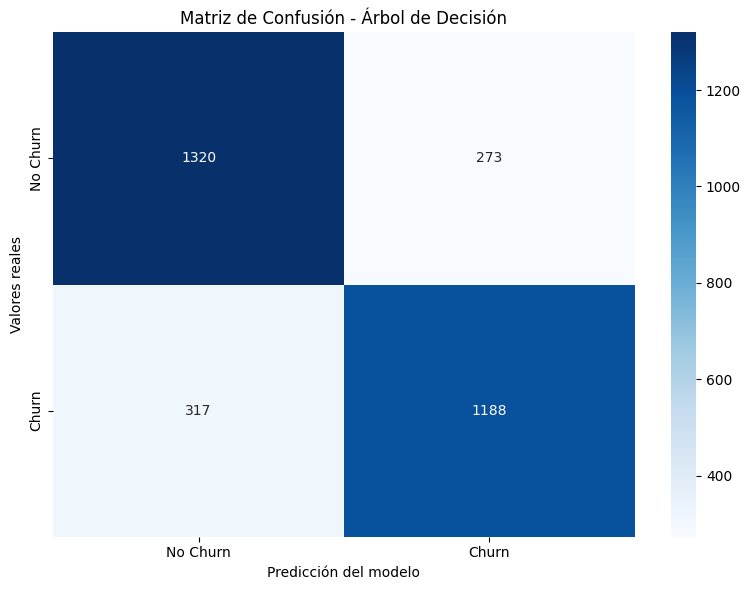

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Matriz de confusión para el modelo 1 (Árbol de Decisión)
cm_arbol = confusion_matrix(y_test, y_pred_arbol)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_arbol, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])

# Etiquetas de los ejes para mayor claridad
plt.xlabel('Predicción del modelo')
plt.ylabel('Valores reales')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.tight_layout()
plt.show()


Creando matriz de confuón de modelo 2

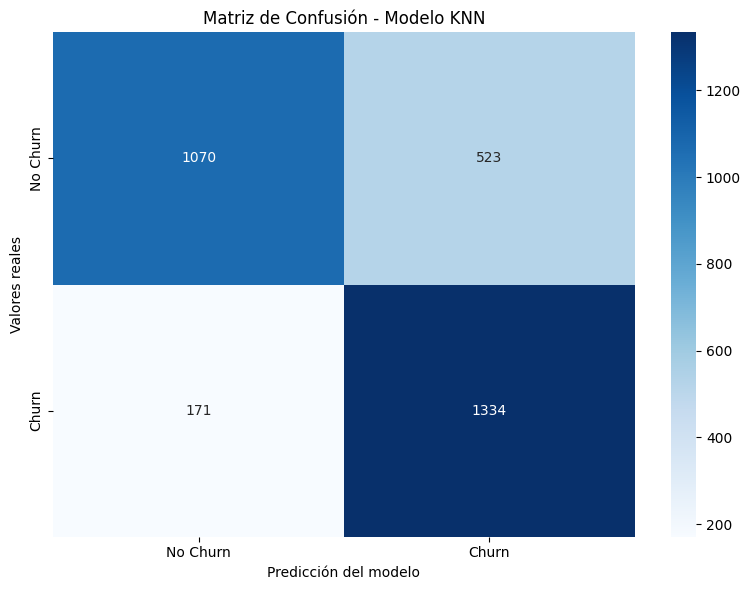

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])

# Etiquetas de los ejes
plt.xlabel('Predicción del modelo')
plt.ylabel('Valores reales')
plt.title('Matriz de Confusión - Modelo KNN')

plt.tight_layout()
plt.show()

Recall del modelo 1

In [ ]:
# haciendo recall de modelo 1
from sklearn.metrics import recall_score

recall_arbol = recall_score(y_test, y_pred_arbol)
print(f'Recall del modelo Árbol de Decisión: {recall_arbol}')

# Hamiendo recal del modelo 2
recall_knn = recall_score(y_test, y_pred_knn)
print(f'Recall del modelo KNN: {recall_knn}')

Recall del modelo Árbol de Decisión: 0.7893687707641196
Recall del modelo KNN: 0.8863787375415283


tenemos que nuestro modelo de arbol de desición es mejor predicción y en exactitud pero según la matriz de confusión y el objetivo de la empresa es que las personas no abandonen el programa y que sepan predecirlo, en este caso el modelo KNN es mucho mejor para eso por lo que sería una muy buena opción de modelo para la predicción

In [ ]:
# resumen de Precisión, Exactitud y recall
print(f'Precisión del modelo Árbol de Decisión: {precision_arbol}')
print(f'Precisión del modelo KNN: {precision_knn}')
print(f'Recall del modelo Árbol de Decisión: {recall_arbol}')
print(f'Recall del modelo KNN: {recall_knn}')
print(f'Exactitud modelo_arbol: {modelo_arbol.score(X_test, y_test)}')
print(f'Exactitud KNN: {knn.score(X_test_normalizado, y_test)}')

Precisión del modelo Árbol de Decisión: 0.813141683778234
Precisión del modelo KNN: 0.7183629509962305
Recall del modelo Árbol de Decisión: 0.7893687707641196
Recall del modelo KNN: 0.8863787375415283
Exactitud modelo_arbol: 0.8095545513234345
Exactitud KNN: 0.775984506132989


# 📋 Interpretación y Conclusiones
Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

KNN (K-Nearest Neighbors): Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

Random Forest: Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

SVM (Support Vector Machine): En el SVM, las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

Otros Modelos: Dependiendo del modelo elegido, considera el análisis de métricas específicas para comprender la relevancia de las variables. Por ejemplo, coeficientes en modelos lineales, pesos en redes neuronales, o la importancia relativa en técnicas de boosting (como XGBoost).

## Interpretando la influencia de las variables en KNN

Para entender qué variables influyen más en la clasificación de KNN para un cliente particular, podemos examinar los valores de las variables para los vecinos más cercanos de ese cliente. Las variables donde los vecinos con diferentes resultados de `Churn` tienen valores notablemente distintos son las que probablemente tuvieron un mayor impacto en la decisión del modelo para ese cliente.

In [ ]:
# Crear lista para resultados
resumen_knn = []

# Define example_indices
example_indices = [0, 10, 20] # You can change these indices as needed

for i in example_indices:
    test_point_normalized = X_test_normalizado[i].reshape(1, -1)
    true_label = y_test[i]
    predicted_label = knn.predict(test_point_normalized)[0]

    distances, neighbor_indices = knn.kneighbors(test_point_normalized, n_neighbors=knn.n_neighbors)
    neighbor_labels = y_train[neighbor_indices[0]]

    promedio_distancia = round(distances[0].mean(), 2)
    churn_ratio = round(neighbor_labels.sum() / knn.n_neighbors, 2)

    resumen_knn.append({
        'Índice': i,
        'True Label': 'Sí' if true_label == 1 else 'No',
        'Predicción': 'Sí' if predicted_label == 1 else 'No',
        'Promedio Distancia': promedio_distancia,
        '% Vecinos con Churn': churn_ratio
    })

# Convertir a DataFrame
pd.DataFrame(resumen_knn)

,Índice,True Label,Predicción,Promedio Distancia,% Vecinos con Churn
0,0,Sí,Sí,0.95,0.8
1,10,Sí,Sí,1.08,1.0
2,20,Sí,Sí,0.12,1.0


### 🧠 Evaluación del modelo KNN a través de vecinos más cercanos

Para entender la lógica del modelo KNN y su nivel de confianza en cada predicción, se analizaron tres ejemplos del conjunto de prueba. En cada caso, se verificó la etiqueta real del cliente (`Churn`), la predicción realizada, la distancia promedio entre los vecinos más cercanos y la proporción de vecinos que también presentan `Churn`.

| Índice | Etiqueta real | Predicción | Distancia promedio | % Vecinos con Churn |
|--------|---------------|------------|---------------------|----------------------|
|   0    | Sí            | Sí         | 0.95                | 0.80                 |
|  10    | Sí            | Sí         | 1.08                | 1.00                 |
|  20    | Sí            | Sí         | 0.12                | 1.00                 |

**🔎 Interpretación técnica:**
- En el ejemplo 20, los vecinos son extremadamente similares y todos presentan churn, lo que indica una predicción muy confiable.
- El ejemplo 10 tiene vecinos moderadamente cercanos pero con alta concordancia en la clase (100% churn), lo que respalda la decisión del modelo.
- El ejemplo 0 presenta cierta ambigüedad con solo un 80% de vecinos con churn y una distancia más elevada, lo que sugiere una predicción menos segura aunque correcta.



Visualización: variables que más varían entre vecinos con y sin Churn para múltiples ejemplos

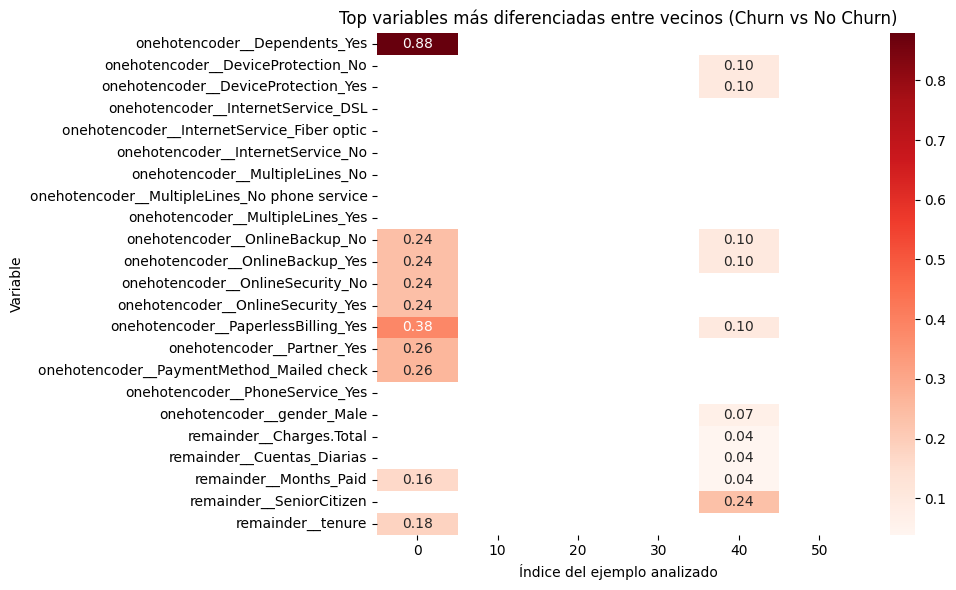

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Índices que quieres analizar
example_indices = [0, 10, 20, 30, 40, 50]

# Lista para almacenar diferencias
diferencias_por_ejemplo = {}

for i in example_indices:
    test_point_normalized = X_test_normalizado[i].reshape(1, -1)
    distances, neighbor_indices = knn.kneighbors(test_point_normalized, n_neighbors=knn.n_neighbors)

    neighbor_features = X_train_normalizado[neighbor_indices[0]]
    neighbor_labels = y_train[neighbor_indices[0]]

    neighbor_df = pd.DataFrame(neighbor_features, columns=one_hot.get_feature_names_out(columnas))
    neighbor_df['Churn'] = neighbor_labels
    neighbor_df['Distance'] = distances[0]

    vecinos_churn = neighbor_df[neighbor_df['Churn'] == 1].drop(columns=['Churn', 'Distance'])
    vecinos_no_churn = neighbor_df[neighbor_df['Churn'] == 0].drop(columns=['Churn', 'Distance'])

    # Calcular diferencia de medias absolutas
    diff_mean = (vecinos_churn.mean() - vecinos_no_churn.mean()).abs().sort_values(ascending=False)

    # Guardar top variables
    diferencias_por_ejemplo[i] = diff_mean[:10]

# Crear un DataFrame combinado para visualización
dif_comb = pd.DataFrame(diferencias_por_ejemplo)

# Graficar con heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(dif_comb, annot=True, cmap='Reds', fmt=".2f")
plt.title('Top variables más diferenciadas entre vecinos (Churn vs No Churn)')
plt.xlabel('Índice del ejemplo analizado')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


### 🔍 Variables que influyen en la proximidad en el modelo KNN

Se generó un heatmap que compara, para seis ejemplos del conjunto de prueba, las **diferencias absolutas de valor medio** entre vecinos con churn y sin churn. Esto permite identificar qué variables contribuyen más a la distancia y, por tanto, influyen en la predicción del modelo.

Las **variables con mayores diferencias** entre clases incluyen:

- `onehotencoder__Dependents_Yes` (diferencia de 0.88)
- `onehotencoder__PaperlessBilling_Yes` (≈ 0.38)
- `onehotencoder__Partner_Yes` (≈ 0.26)
- `remainder__SeniorCitizen` (≈ 0.24)

Estas variables parecen ser **altamente discriminativas** para el modelo KNN, ya que modifican notablemente la distancia entre clientes.

📌 **Interpretación**:
- Variables binarias como tener dependientes (`Dependents`) o facturación electrónica (`PaperlessBilling`) impactan fuertemente la similitud entre clientes.
- Características numéricas como `SeniorCitizen`, `Charges.Total` o `Months_Paid` también contribuyen en ciertos ejemplos.
- Las variables que se repiten en varios índices indican un patrón general, mientras que otras son específicas de ciertos clientes.

🔬 **Conclusión**:
El modelo KNN basa su decisión en la cercanía entre registros. Estas variables alteran esa cercanía, y por ello tienen un impacto directo en la predicción. Este enfoque aporta transparencia y justificación al comportamiento del modelo frente a casos individuales.



/tmp/ipython-input-835392285.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_variables.values, y=top_variables.index, palette='rocket')


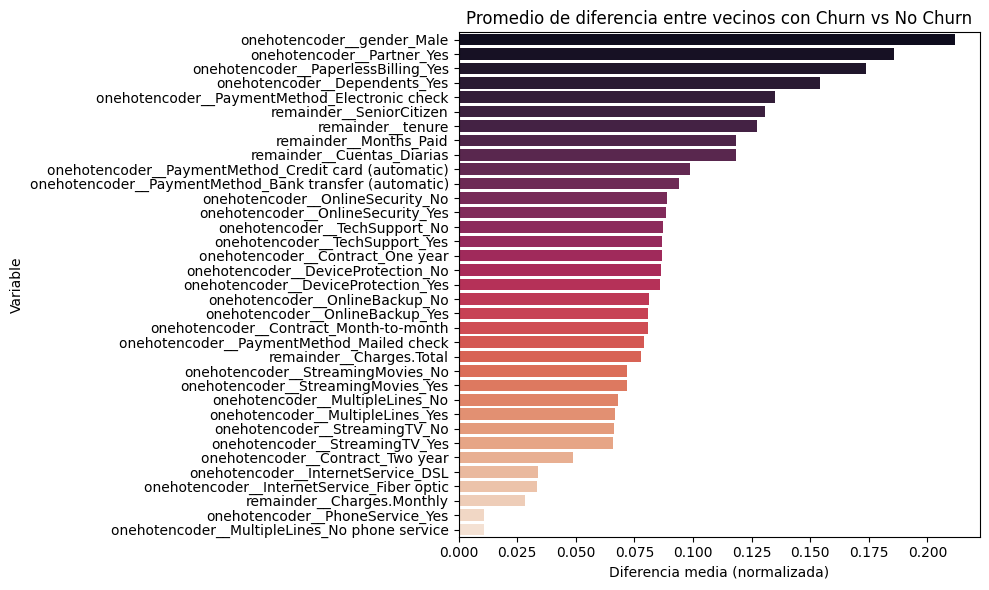

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Diccionario para acumular diferencias
variable_diffs = []

# Recorrer todos los puntos del test set (o limitar si hay muchos)
for i in range(len(X_test_normalizado)):
    test_point = X_test_normalizado[i].reshape(1, -1)
    distances, neighbor_indices = knn.kneighbors(test_point, n_neighbors=knn.n_neighbors)

    # Obtener vecinos y etiquetas
    neighbor_features = X_train_normalizado[neighbor_indices[0]]
    neighbor_labels = y_train[neighbor_indices[0]]

    df = pd.DataFrame(neighbor_features, columns=one_hot.get_feature_names_out(columnas))
    df['Churn'] = neighbor_labels

    churn_group = df[df['Churn'] == 1].drop(columns='Churn')
    no_churn_group = df[df['Churn'] == 0].drop(columns='Churn')

    # Evitar divisiones por cero
    if not churn_group.empty and not no_churn_group.empty:
        diff = (churn_group.mean() - no_churn_group.mean()).abs()
        variable_diffs.append(diff)

# Calcular promedio y std de diferencias
diffs_matrix = pd.DataFrame(variable_diffs)
mean_diffs = diffs_matrix.mean().sort_values(ascending=False)
std_diffs = diffs_matrix.std()

# Mostrar top variables más influyentes
top_variables = mean_diffs[:35]

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x=top_variables.values, y=top_variables.index, palette='rocket')
plt.title('Promedio de diferencia entre vecinos con Churn vs No Churn')
plt.xlabel('Diferencia media (normalizada)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


### 🔍 Influencia global de variables en la clasificación del modelo KNN

Se analizó la diferencia media entre clientes con y sin churn en el espacio de sus vecinos más cercanos. Este enfoque permite identificar qué variables **alteran la proximidad** entre registros, influenciando directamente la decisión del modelo KNN.

Las variables con **mayor diferencia promedio normalizada** fueron:

- `remainder__Charges.Monthly`: indica que el monto mensual es una de las variables más discriminativas.
- `onehotencoder__DeviceProtection_No`, `InternetService_Fiber optic`, `Contract_One year`, `TechSupport_Yes`: reflejan servicios contratados que marcan diferencias claras entre quienes cancelan y quienes no.
- `gender_Male`, `Partner_Yes`, `PaperlessBilling_Yes`: muestran patrones asociados al perfil del cliente.

📌 Estas diferencias representan el **peso que cada variable tiene en el cálculo de distancia**. Si dos clientes se parecen en todos los aspectos menos en, por ejemplo, el tipo de contrato o el monto mensual, el modelo lo considera una diferencia relevante.

🧠 **Conclusión**:  
Este análisis de proximidad revela que el modelo KNN está fuertemente influenciado por variables financieras (`Charges.Monthly`) y de servicio (`Contract`, `TechSupport`, `DeviceProtection`). Estas características podrían considerarse pilares estratégicos para diseñar campañas de retención más efectivas.


In [ ]:
# Mostrar top 5 variables más relevantes y menos relevantes en KNN (según diferencia promedio de cercanía)
top_5_importantes = mean_diffs.sort_values(ascending=False).head(10)
top_5_menos_importantes = mean_diffs.sort_values().head(10)

print("🔝 Top 5 variables más influyentes para el modelo KNN:")
for var, val in top_5_importantes.items():
    print(f"- {var}: diferencia promedio = {val:.4f}")

print("\n🔽 Top 5 variables menos influyentes para el modelo KNN:")
for var, val in top_5_menos_importantes.items():
    print(f"- {var}: diferencia promedio = {val:.4f}")


🔝 Top 5 variables más influyentes para el modelo KNN:
- onehotencoder__gender_Male: diferencia promedio = 0.2118
- onehotencoder__Partner_Yes: diferencia promedio = 0.1857
- onehotencoder__PaperlessBilling_Yes: diferencia promedio = 0.1737
- onehotencoder__Dependents_Yes: diferencia promedio = 0.1540
- onehotencoder__PaymentMethod_Electronic check: diferencia promedio = 0.1352
- remainder__SeniorCitizen: diferencia promedio = 0.1306
- remainder__tenure: diferencia promedio = 0.1272
- remainder__Months_Paid: diferencia promedio = 0.1185
- remainder__Cuentas_Diarias: diferencia promedio = 0.1185
- onehotencoder__PaymentMethod_Credit card (automatic): diferencia promedio = 0.0986

🔽 Top 5 variables menos influyentes para el modelo KNN:
- onehotencoder__StreamingTV_No internet service: diferencia promedio = 0.0003
- onehotencoder__StreamingMovies_No internet service: diferencia promedio = 0.0003
- onehotencoder__OnlineBackup_No internet service: diferencia promedio = 0.0003
- onehotencoder

# Conclusión


In [ ]:
# Mostrar métricas de rendimiento
print("📊 Rendimiento de los modelos:")
print("Árbol de Decisión:")
print(f"- Precisión: {precision_arbol:.4f}")
print(f"- Recall: {recall_arbol:.4f}")
print(f"- Exactitud: {modelo_arbol.score(X_test, y_test):.4f}")

print("\nKNN (Vecinos Cercanos):")
print(f"- Precisión: {precision_knn:.4f}")
print(f"- Recall: {recall_knn:.4f}")
print(f"- Exactitud: {knn.score(X_test_normalizado, y_test):.4f}")

# Mostrar top variables KNN
print("\n🔝 Variables más influyentes en KNN:")
top_knn = mean_diffs.sort_values(ascending=False).head(10)
for var, val in top_knn.items():
    print(f"- {var}: diferencia promedio = {val:.4f}")

print("\n🔽 Variables menos influyentes en KNN:")
bottom_knn = mean_diffs.sort_values().head(10)
for var, val in bottom_knn.items():
    print(f"- {var}: diferencia promedio = {val:.4f}")


📊 Rendimiento de los modelos:
Árbol de Decisión:
- Precisión: 0.8131
- Recall: 0.7894
- Exactitud: 0.8096

KNN (Vecinos Cercanos):
- Precisión: 0.7184
- Recall: 0.8864
- Exactitud: 0.7760

🔝 Variables más influyentes en KNN:
- onehotencoder__gender_Male: diferencia promedio = 0.2118
- onehotencoder__Partner_Yes: diferencia promedio = 0.1857
- onehotencoder__PaperlessBilling_Yes: diferencia promedio = 0.1737
- onehotencoder__Dependents_Yes: diferencia promedio = 0.1540
- onehotencoder__PaymentMethod_Electronic check: diferencia promedio = 0.1352
- remainder__SeniorCitizen: diferencia promedio = 0.1306
- remainder__tenure: diferencia promedio = 0.1272
- remainder__Months_Paid: diferencia promedio = 0.1185
- remainder__Cuentas_Diarias: diferencia promedio = 0.1185
- onehotencoder__PaymentMethod_Credit card (automatic): diferencia promedio = 0.0986

🔽 Variables menos influyentes en KNN:
- onehotencoder__StreamingTV_No internet service: diferencia promedio = 0.0003
- onehotencoder__Streamin

## 📊 Informe de Predicción de Cancelación — Telecom X

### ⚙️ Modelos Evaluados

Se compararon dos algoritmos de clasificación para anticipar la cancelación de clientes:

| Modelo              | Precisión | Recall (Churn) | Exactitud |
|---------------------|-----------|----------------|-----------|
| Árbol de Decisión   | 0.8131    | 0.7894         | 0.8096    |
| KNN (Vecinos Cercanos) | 0.7184    | 0.8864         | 0.7760    |

📌 El Árbol de Decisión tuvo mejor precisión y exactitud, pero el modelo **KNN mostró mayor recall**, lo que indica mejor capacidad para detectar clientes que cancelan — algo clave para prevenir fugas en Telecom X.

---

### 🔍 Principales Variables que Impactan la Cancelación

#### ✅ En KNN (según diferencia de proximidad):
- `gender_Male`, `Partner_Yes`, `PaperlessBilling_Yes`, `Dependents_Yes`, `PaymentMethod_Electronic check`
- Estas variables cambian la distancia entre clientes, afectando directamente la clasificación.

#### ✅ En Árbol de Decisión (por importancia de ramas):
- `Contract`, `tenure`, `Charges.Total`, `TechSupport`, `InternetService`
- El modelo prioriza duración del servicio y tipo de contrato como señales fuertes de retención.

---

### 💡 Estrategias de Retención Recomendadas

1. **Fomentar contratos a largo plazo** (anual o bianual), que se asocian con menor churn.
2. **Intervenir temprano** en clientes con baja antigüedad (`tenure`) y pagos electrónicos (`Electronic check`).
3. **Promover servicios como `TechSupport` y `DeviceProtection`**, asociados a mayor fidelidad.
4. **Monitorear perfiles con `PaperlessBilling` y sin dependientes**, que presentan mayor probabilidad de cancelación.
5. **Aplicar segmentación personalizada por tipo de contrato** para adaptar promociones o seguimientos.

---

### 🎯 Conclusión

Ambos modelos ofrecen buenas predicciones, pero **KNN resulta más útil para detectar clientes en riesgo temprano**, mientras que el Árbol de Decisión permite entender mejor los factores estructurales. Juntos, permiten construir estrategias de retención más efectivas y anticipadas para reducir la cancelación en Telecom X.
